## CPMSC 448 Homework 2
### Problem 4

#### Name:
#### PSU id:


In this problem will use the Pima Indians Diabetes dataset from the UCI repository to experiment with the $k$-NN algorithm and find the optimal value for the number of neighbors  $k$. You do not need to implement the algorithm and encouraged to use the implementation in \texttt{scikit-learn}.


### a) 
Download the provided `Pima.csv` data file and load it using `pandas`. As a sanity check, make sure  there are 768 rows of data (potential diabetes patients) and 9 columns (8 input features including  `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and 1 target output). Note that the data file has no header and you might want to explicitly create the header. The last value in each row contains the target label for that row, and the remaining values are the features. Report the statics of each feature (min, max, average) and the histogram of the labels (target outputs).
    

In [193]:
import numpy as np
import pandas as pd
pd.set_option('display.max.columns', 100)
# to draw pictures in jupyter notebook
%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns
# we don't like warnings
# you can comment the following 2 lines if you'd like to
import warnings
warnings.filterwarnings('ignore')

In [194]:

data = pd.read_csv("Pima.csv", header=None, names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", 
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Result"])
data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Result
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [195]:
data.shape

(768, 9)

In [196]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Result
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [197]:
# max, min, and mean of all features
statistics = data.drop(columns=["Result"]).describe().loc[["mean","max","min"]]
print(statistics)

      Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
mean     3.845052  120.894531      69.105469      20.536458   79.799479   
max     17.000000  199.000000     122.000000      99.000000  846.000000   
min      0.000000    0.000000       0.000000       0.000000    0.000000   

            BMI  DiabetesPedigreeFunction        Age  
mean  31.992578                  0.471876  33.240885  
max   67.100000                  2.420000  81.000000  
min    0.000000                  0.078000  21.000000  


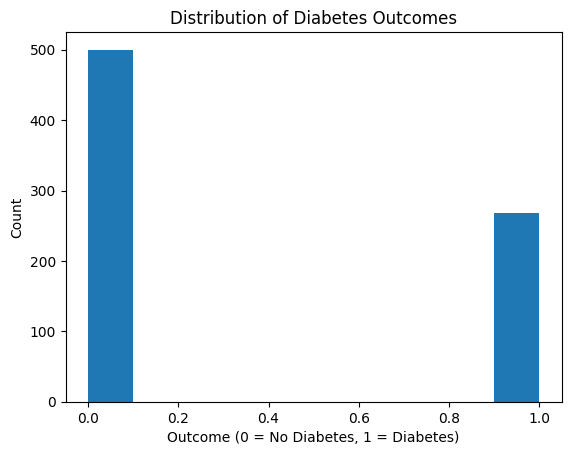

In [198]:
# histogram of labels

# data["Result"].plot(kind= "hist", color= ['blue','orange'])
plt.hist(data["Result"])

plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.title('Distribution of Diabetes Outcomes')
plt.show()



### b) 
Split the data into training and test data with 80\% training and 20\% test data sizes. 

Use 5-fold cross-validation on training data to decide the best number of neighbours $k$. To this end, you can use the built in functionality in  `scikit-learn` such as `cross_val_score`. For $k=1,2,3,\ldots, 15$ compute the 5-fold cross validation error and plot the results  (with values of $k$ on the $x$-axis and accuracy on the $y$-axis). Include the plot in your report and justify your decision for picking a particular number of neighbors $k$.

In [199]:
import sklearn

In [200]:
from sklearn.model_selection import train_test_split
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", 
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
feature_cols = pd.DataFrame(data, columns=cols)
X_train, X_test, y_train, y_test = train_test_split(feature_cols, data['Result'], test_size=0.2, random_state=160)

Text(0.5, 1.0, '5-Fold Cross-Validation Accuracy vs. k-NN')

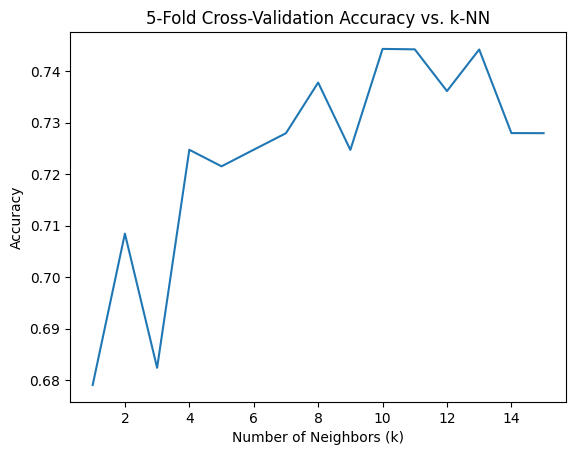

In [201]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

cross_val_scores = []
for k in range(1,16):
    # Create NN classifier
    knn = KNeighborsClassifier(n_neighbors = k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cross_val_scores.append(np.mean(scores))
k_vals = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]   
plt.plot(k_vals, cross_val_scores)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy vs. k-NN")


### c ) 
Evaluate the $k$-NN algorithm on test data with the optimal number of neighbours you obtained in previous step and report the test error.

In [202]:
# optimal number of neighbors in the CV scores using max
optimal_NN = np.argmax(cross_val_scores)+1
print(f"Optimal Number of Neighbors: {optimal_NN}")

Optimal Number of Neighbors: 10


In [203]:
# calculating test error
knn = KNeighborsClassifier(n_neighbors = optimal_NN)
knn.fit(X_train,y_train)
print("Test score: {:.3f}".format(1-knn.score(X_test, y_test)))

Test score: 0.273


### d) 
Process the input data  by subtracting the mean (a.k.a. centralization) and dividing by the standard deviation (a.k.a. standardization) over each dimension (feature),  repeat the previous part and report the accuracy. Do centralization and standardization affect the accuracy? Why?

In [204]:
# looping thru all col values to find std and mean
for i in cols:
    
    mean = data[i].mean()
    std = data[i].std()
    X_test[i] = (X_test[i] - mean)/std
    X_train[i] = (X_train[i] - mean)/std

In [205]:
knn = KNeighborsClassifier(n_neighbors = optimal_NN)
knn.fit(X_train,y_train)
print("Test score: {:.3f}".format(1-knn.score(X_test, y_test)))

Test score: 0.240
